# Week 9 · Day 3 — Convolution, from Scratch to a CNN that Beats the ANN

All week our neural networks have done the same thing to an image: **flattened it** into a long list of pixels. That throws away something huge — *which pixels are next to which*. A face isn’t 2304 unrelated numbers; it’s eyes above a nose above a mouth, and that arrangement is the whole point.

Today we fix it. We’ll learn **convolution** — the operation that lets a network use the 2D shape of an image — starting from the absolute basics, by hand, on a tiny grid. Then we’ll use it to **detect edges** in a real image. Then we’ll build a **Convolutional Neural Network (CNN)** and watch it beat the ANN ceiling we hit on FER2013 last week.

**Today’s plan:**
1. **What is a convolution?** — by hand, on a 6×6 grid.
2. **Edge detection** — real filters on a real image; *see* what a feature map is.
3. **Convolution in PyTorch** — `nn.Conv2d`, the same idea, done for us.
4. **Build a CNN** on FER2013 — and beat last week’s ANN.

> No new math you can’t follow. A convolution is just “multiply a little window, add it up, slide over.” We’ll do it by hand first so the framework is never a black box.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=120)

---
## 1. What is a convolution?

Forget images for a second. A convolution is a tiny, simple operation:

> Take a small grid of numbers called a **kernel** (or **filter**) — say 3×3. Place it over a patch of the image. **Multiply each overlapping pair, add them all up** — that single number is the output. Then **slide** the kernel one step over and repeat.

That’s it. Multiply, sum, slide. Let’s do exactly one step by hand.

In [2]:
# a tiny 6x6 'image' (just numbers for now)
image = np.array([
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
], dtype=float)

# a 3x3 kernel that detects a vertical edge (left-to-right change)
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=float)

print("image:\n", image.astype(int))
print("\nkernel (vertical-edge detector):\n", kernel.astype(int))

image:
 [[10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]]

kernel (vertical-edge detector):
 [[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


Notice the image: the **left half is bright (10), the right half is dark (0)** — there’s a vertical edge right down the middle. Let’s convolve one 3×3 patch and see what the kernel does at the edge.

In [3]:
# take the 3x3 patch sitting right on the edge (columns 1,2,3 of the top rows)
patch = image[0:3, 1:4]
print("patch (sitting on the edge):\n", patch.astype(int))

# convolution at this spot = multiply overlapping numbers, then sum
products = patch * kernel
result = products.sum()

print("\npatch * kernel (elementwise):\n", products.astype(int))
print("\nsum of all of them =", result, " <-- one output number")

patch (sitting on the edge):
 [[10 10  0]
 [10 10  0]
 [10 10  0]]

patch * kernel (elementwise):
 [[-10   0   0]
 [-10   0   0]
 [-10   0   0]]

sum of all of them = -30.0  <-- one output number


A big number came out (**-30**) because the kernel sat **on an edge** — bright on its left, dark on its right, which is exactly the pattern `[-1, 0, 1]` responds to. Where there’s no edge, it gives ~0. That’s the magic: **a kernel outputs a strong number wherever its pattern appears, and near zero elsewhere.**

Let’s prove it by sliding the kernel over the *whole* image — that’s a full convolution.

In [4]:
def convolve2d(image, kernel):
    """Slide the kernel over the image: multiply, sum, step. Return the feature map."""
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="edge")   # pad so output is same size
    output = np.zeros_like(image, dtype=float)
    for i in range(image.shape[0]):          # every row
        for j in range(image.shape[1]):      # every column
            patch = padded[i:i+kh, j:j+kw]   # the little window
            output[i, j] = (patch * kernel).sum()   # multiply + sum
    return output

feature_map = convolve2d(image, kernel)
print("feature map (output of sliding the edge-kernel over the image):\n")
print(feature_map.astype(int))

feature map (output of sliding the edge-kernel over the image):

[[  0   0 -30 -30   0   0]
 [  0   0 -30 -30   0   0]
 [  0   0 -30 -30   0   0]
 [  0   0 -30 -30   0   0]
 [  0   0 -30 -30   0   0]
 [  0   0 -30 -30   0   0]]


Read that output. The numbers are **near 0 everywhere except the middle column**, where the edge is — there they spike. The convolution turned the image into a map of *“where is a vertical edge?”* — this is a **feature map**.

Three words, locked in:
- **kernel / filter** — the small grid of numbers (here 3×3).
- **convolution** — sliding it over the image (multiply, sum, step).
- **feature map** — the output; it lights up where the kernel’s pattern appears.

---
## 2. Edge detection on a real image

Toy grids are clear, but the point lands when you *see* it. Let’s build an image with real shapes and run actual edge-detecting kernels over it.

We make the image with code (no file needed) so this runs anywhere — a bright square, a bar, and a diagonal line.

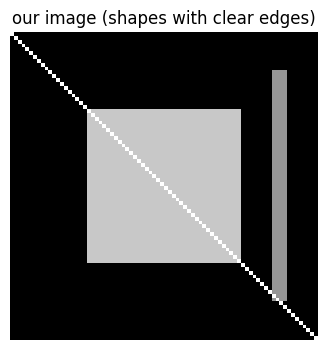

In [16]:
# a synthetic grayscale image with clear edges
img = np.zeros((80, 80), dtype=float)
img[20:60, 20:60] = 200        # a filled square
img[10:70, 68:72] = 150        # a vertical bar
for i in range(80):            # a diagonal line
    img[i, min(i, 79)] = 255

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("our image (shapes with clear edges)")
plt.axis("off")
plt.show()

### The Sobel edge kernels
These are famous hand-designed edge detectors. One finds **vertical** edges (left-right brightness changes), the other **horizontal** edges (up-down changes). Same convolution as before — just a real image.

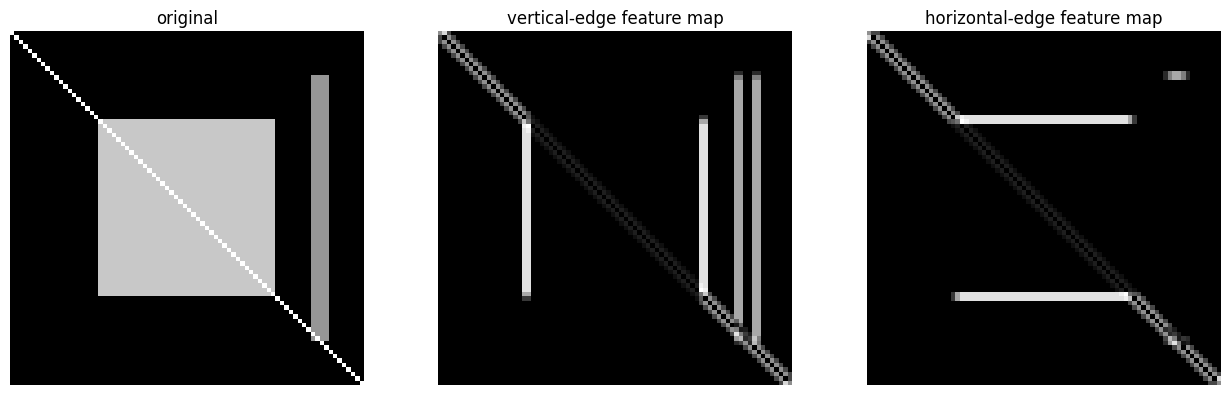

In [17]:
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)

sobel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1],
], dtype=float)

# run our own convolution from Part 1 — same function!
edges_v = convolve2d(img, sobel_vertical)
edges_h = convolve2d(img, sobel_horizontal)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap="gray");            axes[0].set_title("original")
axes[1].imshow(np.abs(edges_v), cmap="gray"); axes[1].set_title("vertical-edge feature map")
axes[2].imshow(np.abs(edges_h), cmap="gray"); axes[2].set_title("horizontal-edge feature map")
for a in axes: a.axis("off")
plt.tight_layout()
plt.show()

In [9]:
img = plt.imread(r'Fig1016(a)(building_original).tif')

In [11]:
img.shape

(834, 1114)

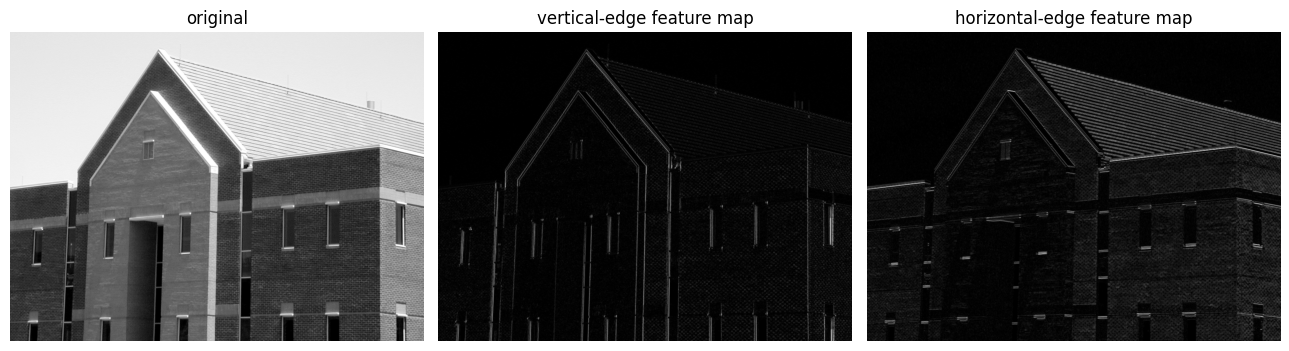

In [12]:
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)

sobel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1],
], dtype=float)

# run our own convolution from Part 1 — same function!
edges_v = convolve2d(img, sobel_vertical)
edges_h = convolve2d(img, sobel_horizontal)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap="gray");            
axes[0].set_title("original")
axes[1].imshow(np.abs(edges_v), cmap="gray"); 
axes[1].set_title("vertical-edge feature map")
axes[2].imshow(np.abs(edges_h), cmap="gray"); 
axes[2].set_title("horizontal-edge feature map")
for a in axes: a.axis("off")
plt.tight_layout()
plt.show()

Look at the difference:
- The **vertical** detector lights up the **left and right sides** of the square and the vertical bar — but not their top/bottom edges.
- The **horizontal** detector lights up the **top and bottom** of the square — but not the sides.
- The diagonal shows up in both, because it has both kinds of edge.

**Same operation, different kernel, different feature detected.** That’s the entire idea of convolution for images.

### Combine them: total edge strength
Add the two together (as magnitude) and you get a full outline of every shape — a classic edge detector built from two convolutions.

In [14]:
25 * 25 * 5

3125

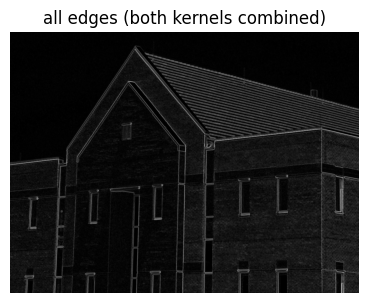

In [13]:
edge_strength = np.sqrt(edges_v**2 + edges_h**2)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(edge_strength, cmap="gray")
plt.title("all edges (both kernels combined)")
plt.axis("off")
plt.show()

### The key leap to CNNs

We **hand-designed** those edge kernels. But what if we don’t know the right filters for a hard problem like faces? What patterns detect an eye, a smile, a frown?

**A CNN doesn’t hand-design its filters — it *learns* them.** During training, the network discovers, by gradient descent, whatever kernels are most useful for the task: edges in the early layers, then curves and textures, then whole features like eyes and mouths in deeper layers. Same convolution operation we just built — but the kernel numbers are learned weights, not fixed.

That’s a CNN. Now let’s build one.

---
## 3. Convolution in PyTorch

Our hand-written `convolve2d` was two Python loops — clear, but slow. PyTorch’s **`nn.Conv2d`** does the exact same thing, fast, and (crucially) with **learnable** kernels.

One quick check first: it does the same job as our function.

In [26]:
import torch
import torch.nn as nn

# put our Sobel kernel into a Conv2d layer and run it on the same image
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    conv.weight[:] = torch.tensor(sobel_vertical, dtype=torch.float32).reshape(1, 1, 3, 3)

# PyTorch wants shape (batch, channels, height, width)
img_t = torch.tensor(img, dtype=torch.float32).reshape(1, 1, 80, 80)
out = conv(img_t).detach().numpy()[0, 0]

In [25]:
out.detach().numpy()[0, 0]

array([[ 255., -510., -255., ...,    0.,    0.,    0.],
       [ 510.,    0., -510., ...,    0.,    0.,    0.],
       [ 255.,  510.,    0., ...,    0.,    0.,    0.],
       ...,
       [   0.,    0.,    0., ...,    0., -510., -255.],
       [   0.,    0.,    0., ...,  510.,    0., -510.],
       [   0.,    0.,    0., ...,  255.,  510., -255.]], dtype=float32)

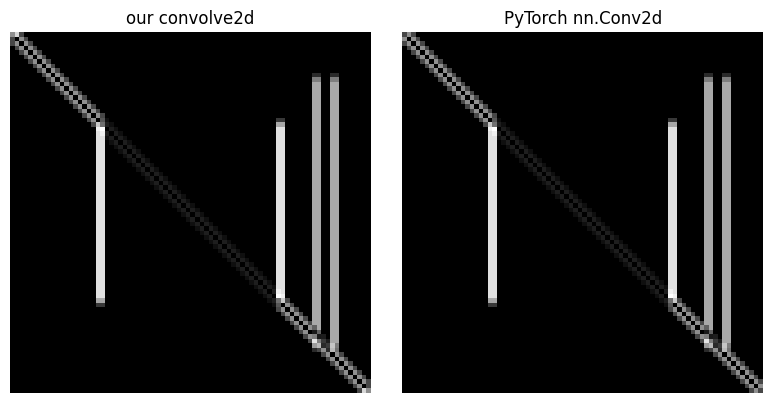

same result — nn.Conv2d IS the convolution we built, just faster.


In [27]:


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(np.abs(edges_v), cmap="gray");  axes[0].set_title("our convolve2d")
axes[1].imshow(np.abs(out), cmap="gray");       axes[1].set_title("PyTorch nn.Conv2d")
for a in axes: a.axis("off")
plt.tight_layout()
plt.show()
print("same result — nn.Conv2d IS the convolution we built, just faster.")

Essentially identical (any tiny difference is only at the very border, because our hand-written version and PyTorch pad the edges slightly differently — the interior matches exactly). `nn.Conv2d` is our loop, optimized. The difference in a real CNN: we **don’t set the kernel** — we let PyTorch start it random and *learn* it during training.

**The one shape rule to remember:** conv layers need images in the shape **`(batch, channels, height, width)`** — they keep the 2D structure. This is the opposite of the ANN, where we flattened to `(batch, pixels)`. **From now on: don’t flatten before the conv layers.**

---
## 4. Build a CNN on FER2013 — and beat the ANN

Last week a plain ANN reached only ~35–45% on FER2013 faces, because flattening destroyed the 2D structure. Now we give the network convolutions and let it keep that structure. Let’s see the difference.

### Load the data (same folders as last week, but keep the 2D shape)

In [28]:
import os
from PIL import Image

DATA_DIR = r"..\datasets\FER2013"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

class_names = sorted([n for n in os.listdir(TRAIN_DIR)
                      if os.path.isdir(os.path.join(TRAIN_DIR, n))])
IMG_SIZE = 48

def load_split(split_dir):
    X, y = [], []
    for label_index, class_name in enumerate(class_names):
        folder = os.path.join(split_dir, class_name)
        if not os.path.isdir(folder):
            continue
        for filename in os.listdir(folder):
            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            try:
                im = Image.open(os.path.join(folder, filename)).convert("L").resize((IMG_SIZE, IMG_SIZE))
                X.append(np.array(im))
                y.append(label_index)
            except Exception as e:
                print("skipped", filename, e)
    return np.array(X, dtype="float32"), np.array(y)

print("classes:", class_names)
print("loading train..."); 
X_train_img, y_train = load_split(TRAIN_DIR)
print("loading test...");  
X_test_img,  y_test  = load_split(TEST_DIR)
print("train:", X_train_img.shape, " test:", X_test_img.shape)

classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
loading train...
loading test...
train: (28709, 48, 48)  test: (7178, 48, 48)


### Prepare — keep the (channel, height, width) shape, do NOT flatten
This is the big change from the ANN. The ANN reshaped to `(N, 2304)`. A CNN needs `(N, 1, 48, 48)` — N images, 1 channel (grayscale), 48×48. We just scale by 255 and add the channel dimension.

In [29]:
# scale 0-1 and reshape to (N, 1, 48, 48) — the channel dimension stays!
X_train = (X_train_img / 255.0).reshape(-1, 1, IMG_SIZE, IMG_SIZE)
X_test  = (X_test_img  / 255.0).reshape(-1, 1, IMG_SIZE, IMG_SIZE)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

n_classes = len(class_names)
print("CNN input shape:", X_train_t.shape, "  <- (N, channels, height, width), NOT flattened")
print("classes:", n_classes)

CNN input shape: torch.Size([28709, 1, 48, 48])   <- (N, channels, height, width), NOT flattened
classes: 7


### Build the CNN
The standard pattern: **convolution → activation → pooling**, repeated, then flatten and a normal classifier on top.

- **`nn.Conv2d`** — learns filters (like our edge kernels, but learned). We ask for several filters per layer so it can learn several patterns at once.
- **`nn.MaxPool2d(2)`** — shrinks the feature map by half, keeping the strongest signals (more efficient, more robust). We’ll cover pooling properly tomorrow — today just know it halves the size.
- **`nn.Flatten` + `nn.Linear`** — only *after* the conv layers have extracted features do we flatten and classify.

The conv part does the four-move training loop you already know — only the model is new.

In [30]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 1 -> 16 feature maps, 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> 24x24
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16 -> 32 maps, 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> 12x12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # only NOW do we flatten
            nn.Linear(32 * 12 * 12, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)      # conv + pool feature extractor
        x = self.classifier(x)    # flatten + dense classifier
        return x

torch.manual_seed(42)
model = SimpleCNN(n_classes)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)


> **Where does `32 * 12 * 12` come from?** Track the shape: start 48×48 → first pool → 24×24 → second pool → 12×12, with 32 feature maps. So the flattened size is `32 × 12 × 12`. Tracking the shape through the layers is the #1 skill for building CNNs — get it wrong and PyTorch throws a size error right here.

### Train it — the same four moves as always
Nothing new in the loop. Forward → loss → backward → update. Only the model changed.

In [31]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 15
test_accs = []
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        acc = (model(X_test_t).argmax(1) == y_test_t).float().mean().item()
    test_accs.append(acc)
    print(f"epoch {epoch+1:2d}  test acc {acc:.2%}")

RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1058439168 bytes.

In [ ]:
plt.plot(range(1, EPOCHS+1), [a*100 for a in test_accs], marker="o", color="green")
plt.axhline(43, color="red", linestyle="--", label="ANN ceiling (~43%)")
plt.xlabel("epoch"); plt.ylabel("test accuracy (%)")
plt.title("CNN on FER2013 — climbing past the ANN")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### The payoff: CNN vs ANN, head to head

In [ ]:
cnn_acc = test_accs[-1]
ann_acc = 0.43   # last week's ANN result on FER2013 (roughly)

print(f"ANN (last week, flattened):  ~{ann_acc:.0%}")
print(f"CNN (today, keeps 2D shape):  {cnn_acc:.0%}")
print(f"\nimprovement: +{(cnn_acc-ann_acc)*100:.0f} percentage points")

plt.bar(["ANN\n(flattened)", "CNN\n(convolution)"], [ann_acc*100, cnn_acc*100],
        color=["gray", "green"])
plt.ylabel("test accuracy (%)")
plt.title("Same dataset, same effort — convolution wins")
for i, v in enumerate([ann_acc*100, cnn_acc*100]):
    plt.text(i, v+1, f"{v:.0f}%", ha="center")
plt.show()

### Confusion matrix — what got better

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    test_pred = model(X_test_t).argmax(1)

cm = confusion_matrix(y_test_t, test_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title(f"CNN confusion matrix — {cnn_acc:.1%}")
plt.tight_layout()
plt.show()

The CNN typically improves most on the emotions with **distinctive shapes** — a smile for *happy*, wide eyes for *surprise* — because convolution can actually see those shapes, which the flattened ANN never could. It still struggles with the genuinely ambiguous ones (fear/sad/neutral) and the rare *disgust* class, just less than the ANN did.

### See what the CNN learned
Remember our hand-made edge kernels? The CNN’s **first conv layer** learned its own filters. Let’s look at a few — many will resemble edge and blob detectors, discovered automatically.

In [ ]:
# the learned filters of the first conv layer
filters = model.features[0].weight.detach().numpy()   # shape (16, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(filters[i, 0], cmap="gray")
    ax.axis("off")
plt.suptitle("The 16 filters the CNN learned in its first layer (no one designed these)")
plt.tight_layout()
plt.show()

Nobody programmed those. The network **learned** them from the faces, the same way we hand-built the Sobel kernel — except it found whatever patterns were most useful for reading emotions. That is the entire idea of a CNN.

### Your turn (practice) ✍️
Pick at least two:
1. **Add a third conv block** (`Conv2d(32, 64) → ReLU → MaxPool2d(2)`). Remember to update the `nn.Linear` input size — track the shape! (48→24→12→6, so `64*6*6`.) Does accuracy improve?
2. **Change the number of filters** in the first layer (try 8, or 32). More filters = more patterns, but slower.
3. **Train longer** (25 epochs). Where does test accuracy plateau — and does train accuracy keep rising (overfitting)?
4. **Remove the pooling layers** and see what breaks (hint: the flattened size changes, and it’s much bigger).

In [ ]:
# ===== YOUR EXPERIMENTS HERE =====



---
## Summary

- A **convolution** is dead simple: place a small **kernel** on a patch, **multiply and sum**, then **slide**. We built it by hand in two loops.
- The output is a **feature map** — it lights up wherever the kernel’s pattern appears. We saw hand-made **edge kernels** (Sobel) outline real shapes.
- **`nn.Conv2d`** is exactly that operation, fast — but with **learnable** kernels. A **CNN learns its own filters** instead of us designing them.
- CNNs keep the image in **`(channels, height, width)`** shape — **no flattening** before the conv layers. That’s the whole reason they beat the ANN on images.
- The standard block is **Conv → ReLU → Pool**, repeated, then flatten and classify. The training loop is the **same four moves** as always.
- On FER2013, the CNN **beat last week’s ANN** — because it can finally see the 2D structure of a face.

You went from “what is a convolution?” to a working CNN that outperforms everything we built before, and you saw it **learn its own edge detectors**.

**Tomorrow:** the architecture in depth — pooling, stride, and padding — and a stronger CNN on a new, colorful dataset.